# M5 HPO · Chronos-2 Smoothness-Ensemble Context Length
Tunes one context length per demand class (Smooth / Erratic / Intermittent / Lumpy).
Each Optuna trial runs **4 separate Chronos-2 zero-shot models** — one per class — each
seeing only its segment's series, then merges all forecasts into one ensemble DF and
evaluates the combined WRMSSE.  Batch size is fixed at 64.

Because each segment × CL forecast is cached independently, cross-trial cache hits
make repeated CLs essentially free.

# 1 · Imports

In [14]:
import os
import sys
sys.path.append("/home/nmwamsojo/tsfm-explo/src/jobs/")

import gc
import json
import torch
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from m5_dataprep import M5DataPipeline
from m5_exploration import (
    M5ExplorationSuite,
    DEFAULT_CHRONOS_CONFIG,
)
from m5_evaluator import M5Evaluator

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

CUDA available: True
  GPU 0: Quadro RTX 5000
  GPU 1: Quadro RTX 5000


In [15]:
os.environ["OMP_NUM_THREADS"]        = "1"
os.environ["MKL_NUM_THREADS"]        = "1"
os.environ["OPENBLAS_NUM_THREADS"]   = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"]    = "1"
os.environ["CUDA_VISIBLE_DEVICES"]   = "0,1"

INFERENCE_DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

# 2 · Config
**Edit this cell only** to change experiment settings.

In [16]:

# ── Data ──────────────────────────────────────────────────────────────────────
DATA_PATH     = "/mnt/lab/datasets/M5/jointed_M5.parquet"
CALENDAR_PATH = "/mnt/lab/nmwamsojo/m5_data/calendar.csv"
ACTUALS_PATH  = "/mnt/lab/nmwamsojo/m5_data/sales_test_evaluation.csv"
DATA_TAG      = "sales_only"   # cache already contains all covariate columns

CUTOFF_DAY = (
    pd.to_datetime("2016-05-22") - pd.Timedelta(days=28)
).strftime("%Y-%m-%d")
print(f"Cutoff day: {CUTOFF_DAY}")

# ── Context-length search space ────────────────────────────────────────────────
CL_CHOICES = [2**i for i in range(9)]   # [1, 2, 4, 8, ..., 1024]
BATCH_SIZE = 64                           # fixed across all trials
N_TRIALS   = 100                          # Optuna budget

# ── Covariate search space ─────────────────────────────────────────────────────
# One shared cov_type per trial (same for all 4 segments).
# DATA_TAG stays fixed — the cached parquet already has all columns.
# Covariate choice is encoded in exp_tag for per-(segment, CL, cov) caching.
COVARIATE_OPTIONS = {
    #"only":        [],
    "is_weekend":  ["is_friday", "is_saturday", "is_sunday"],
    "event":       ["event_name_1", "event_type_1"],
    "price":       ["sell_price"],
    'snap' :       ['snap_CA', 'snap_TX', 'snap_WI'],
    "is_weekend_event":  ["is_friday", "is_saturday", "is_sunday", "event_name_1", "event_type_1"],
    "is_weekend_price":  ["is_friday", "is_saturday", "is_sunday", "sell_price"],
    "event_price": ["event_name_1", "event_type_1", "sell_price"],

    # SNAP + Single Core Features
    "is_weekend_snap": ["is_friday", "is_saturday", "is_sunday", "snap_CA", "snap_TX", "snap_WI"],
    "event_snap":      ["event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"],
    "price_snap":      ["sell_price", "snap_CA", "snap_TX", "snap_WI"],

    # SNAP + Multi-Core Combinations
    "is_weekend_event_snap": ["is_friday", "is_saturday", "is_sunday", "event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"],
    "is_weekend_price_snap": ["is_friday", "is_saturday", "is_sunday", "sell_price", "snap_CA", "snap_TX", "snap_WI"],
    "event_price_snap":      ["event_name_1", "event_type_1", "sell_price", "snap_CA", "snap_TX", "snap_WI"],

    "all": ["is_friday", "is_saturday", "is_sunday", "event_name_1", "event_type_1", "sell_price", "snap_CA", "snap_TX", "snap_WI"],
}

COV_CHOICES = list(COVARIATE_OPTIONS.keys())

print(f"CL search space  : {CL_CHOICES}")
print(f"Cov options      : {COV_CHOICES}")
print(f"Batch size       : {BATCH_SIZE}  (fixed)")
print(f"# combinations   : {len(CL_CHOICES)**4 * len(COV_CHOICES):,}  →  sampling {N_TRIALS} via TPE")

# ── AutoGluon wrapper (shared across all segment runs) ────────────────────────
WRAPPER = {
    "eval_metric":          "RMSSE",
    "enable_ensemble":      False,
    "skip_model_selection": True,
    "verbosity":            1,
}

# ── Base Chronos config — CL, batch_size, known_cov_cols overridden per trial ──
CFG_CHRONOS_ZEROSHOT = {
    **DEFAULT_CHRONOS_CONFIG,
    "fine_tune_steps": 0,
    "use_static":      False,
    "device":          INFERENCE_DEVICE,
}


Cutoff day: 2016-04-24
CL search space  : [1, 2, 4, 8, 16, 32, 64, 128, 256]
Cov options      : ['is_weekend', 'event', 'price', 'snap', 'is_weekend_event', 'is_weekend_price', 'event_price', 'is_weekend_snap', 'event_snap', 'price_snap', 'is_weekend_event_snap', 'is_weekend_price_snap', 'event_price_snap', 'all']
Batch size       : 64  (fixed)
# combinations   : 91,854  →  sampling 100 via TPE


# 3 · Data

In [17]:
pipeline = M5DataPipeline(config={"tag": DATA_TAG})
hist_df, hist_df_trimmed, future_df, static_df, weights_scales = (
    pipeline.get_prepared_data(DATA_PATH, CUTOFF_DAY, level=12, force_reprepare=False)
)

print(f"\nhist_df       : {hist_df.shape}  cols: {list(hist_df.columns)}")
print(f"hist_df_trimmed : {hist_df_trimmed.shape}")
print(f"future_df       : {future_df.shape}")
print(f"static_df       : {static_df.shape}")
print(f"weights_scales  : {weights_scales.shape}  levels: {sorted(weights_scales['level'].unique())}")

del pipeline
gc.collect()

--- Cache Hit: Data found in /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424 ---

hist_df       : (58327370, 21)  cols: ['id', 'date', 'sales_quantity', 'wm_yr_wk', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'is_friday', 'is_saturday', 'is_sunday']
hist_df_trimmed : (45942500, 21)
future_df       : (853720, 20)
static_df       : (30490, 6)
weights_scales  : (42840, 7)  levels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


45

In [18]:
def _wide_to_long(gt_wide: pd.DataFrame, calendar_path: str) -> pd.DataFrame:
    if "id" not in gt_wide.columns:
        gt_wide["id"] = gt_wide["item_id"] + "_" + gt_wide["store_id"] + "_evaluation"
    day_cols = [c for c in gt_wide.columns if c.startswith("d_")]
    long = gt_wide.melt(id_vars=["id"], value_vars=day_cols,
                        var_name="d", value_name="sales_quantity")
    cal = pd.read_csv(calendar_path, usecols=["d", "date"])
    cal["date"] = pd.to_datetime(cal["date"])
    long = long.merge(cal, on="d", how="left").drop(columns=["d"])
    long["id"] = long["id"].str.replace("_evaluation", "", regex=False)
    return long[["id", "date", "sales_quantity"]]


if CUTOFF_DAY == "2016-05-22":  # evaluation phase — held-out test set
    print("Loading evaluation actuals from CSV (wide format)...")
    _eval_raw = pd.read_csv(ACTUALS_PATH)
    df_actual = _wide_to_long(_eval_raw, CALENDAR_PATH)
    del _eval_raw
else:
    df_actual = (
        pd.read_parquet(DATA_PATH, columns=["id", "date", "sold"])
        .rename(columns={"sold": "sales_quantity"})
    )
    df_actual["id"] = (
        df_actual["id"].astype(str)
        .str.replace("_evaluation", "", regex=False)
        .str.replace("_validation",  "", regex=False)
    )

print(f"Actuals : {hist_df_trimmed.shape}  |  "
      f"{hist_df_trimmed['date'].min().date()} → {hist_df_trimmed['date'].max().date()}")

print(f"Actuals : {df_actual.shape}  |  "
      f"{df_actual['date'].min().date()} → {df_actual['date'].max().date()}")

Actuals : (45942500, 21)  |  2011-01-29 → 2016-04-24
Actuals : (59181090, 3)  |  2011-01-29 → 2016-05-22


# 4 · Evaluator & Suite
Initialised **once** — reused across all trials to avoid redundant scale/weight computation.

In [19]:
evaluator = M5Evaluator(
    raw_train_df     = hist_df,
    trimmed_train_df = hist_df_trimmed,
    static_df        = static_df,
    weights_df       = weights_scales,
    target_col       = "sales_quantity",
    price_col        = "sell_price",
)
suite = M5ExplorationSuite(
    horizon  = 28,
    ag_path  = "/mnt/lab/nmwamsojo/autogluon_models/explorations",
    base_dir = "/mnt/lab/nmwamsojo/prepared_data",
)

  [CPU] CuPy not available — scale computation on 18 CPU cores.
  Building hierarchy scales and weights …


# 5 · Segment ID Map
Build a `{segment → [id, …]}` dict from the pre-computed `smoothness_segs` column.
`"Undefined"` series (all-zero or single-sale demand) are folded into `"Lumpy"` —
the most irregular class and the closest structural match.

In [20]:
import pandas as pd

# Define the descriptive labels from lowest weight to highest weight
quantile_labels = ['Low', 'Medium-Low', 'Medium-High', 'High']

# Create the new column
weights_scales['weight_segs'] = pd.qcut(
    weights_scales['weight'], 
    q=4, 
    labels=quantile_labels
)

In [21]:
# Prefer the column from hist_df_trimmed (set by pipeline cache);
# fall back to weights_scales at L12 if the column was never propagated there.

seg_columns  = "weight_segs"   # "weight_segs" or "smoothness_segs"
seg_names    = ["Smooth", "Erratic", "Intermittent", "Lumpy"]
undefined_in = "Lumpy"

if "weight" in seg_columns:
    seg_names    = quantile_labels
    undefined_in = "Low"

# Scheme identifier used in cache tags — shared across all classes with the same
# (CL, cov_type) so a single forecast file is reused instead of one per class.
seg_scheme = seg_columns.replace("_segs", "")   # "weight" or "smoothness"

if seg_columns in hist_df_trimmed.columns:
    _seg_src = hist_df_trimmed[["id", seg_columns]].drop_duplicates()
else:
    _seg_src = (
        weights_scales[weights_scales["level"] == 12][["id", seg_columns]]
        .dropna(subset=[seg_columns])
    )

seg_id_map = {
    seg: _seg_src[_seg_src[seg_columns] == seg]["id"].tolist()
    for seg in seg_names
}

# Fold "Undefined" into the most irregular class
_undefined = _seg_src[_seg_src[seg_columns] == "Undefined"]["id"].tolist()
seg_id_map[undefined_in].extend(_undefined)

del _seg_src, _undefined

total = sum(len(v) for v in seg_id_map.values())
for seg, ids in seg_id_map.items():
    print(f"  {seg:>14}: {len(ids):>6,} series  ({100*len(ids)/total:.1f}%)")
print(f"  {'TOTAL':>14}: {total:>6,}")
print(f"\n  seg_scheme = '{seg_scheme}'")

             Low:  9,835 series  (32.3%)
      Medium-Low:  9,349 series  (30.7%)
     Medium-High:  7,688 series  (25.2%)
            High:  3,618 series  (11.9%)
           TOTAL: 30,490

  seg_scheme = 'weight'


# 6 · Optuna HPO
Each trial samples one `context_length` per class and runs 4 segment-specific
Chronos models.  The per-segment forecast cache key is `(segment, CL)`, so CLs
that repeat across trials are loaded from disk rather than re-inferred.

In [22]:
SEG_PARAM = {seg: f"CL_{seg.lower()}" for seg in seg_names}


def objective(trial: optuna.Trial) -> float:
    # ── 1. Sample hyperparameters ─────────────────────────────────────────────
    seg_cl = {
        seg: trial.suggest_categorical(param, CL_CHOICES)
        for seg, param in SEG_PARAM.items()
    }
    cov_type       = trial.suggest_categorical("cov_type", COV_CHOICES)
    known_cov_cols = COVARIATE_OPTIONS[cov_type]

    print(
        f"\n[Trial {trial.number}] "
        f"CLs={{{', '.join(f'{p}={seg_cl[s]}' for s, p in SEG_PARAM.items())}}}  "
        f"cov={cov_type}"
    )

    seg_forecasts = []
    try:
        # ── 2. Run one Chronos model per segment ─────────────────────────────
        for seg_name, cl in seg_cl.items():
            # Tag encodes (scheme, CL, cov_type) — all segment classes with the same
            # CL+cov share one cached forecast file, so repeated combos across trials
            # and across segment classes cost nothing.
            seg_tag = f"hpo_zs_{seg_scheme}_cl{cl}_{cov_type}"
            ids     = set(seg_id_map[seg_name])

            fcst = suite.run(
                hist_df      = hist_df_trimmed,
                future_df    = future_df,
                static_df    = static_df,
                model        = "Chronos2",
                exp_config   = {**CFG_CHRONOS_ZEROSHOT,
                                "context_length": cl,
                                "batch_size":     BATCH_SIZE,
                                "known_cov_cols": known_cov_cols},
                exp_tag      = seg_tag,
                data_tag     = DATA_TAG,
                cutoff_day   = CUTOFF_DAY,
                wrapper_dict = WRAPPER,
                force_run    = False,
            )

            seg_forecasts.append(fcst[fcst["id"].isin(ids)].copy())
            del fcst

        # ── 3. Merge all segment forecasts → one ensemble DF ─────────────────
        ensemble_fcst = pd.concat(seg_forecasts, ignore_index=True)
        seg_forecasts.clear()

        # ── 4. Evaluate ensemble ──────────────────────────────────────────────
        metrics = evaluator.evaluate_all(ensemble_fcst, df_actual)
        del ensemble_fcst

        for seg, param in SEG_PARAM.items():
            trial.set_user_attr(param, seg_cl[seg])
        trial.set_user_attr("cov_type", cov_type)
        trial.set_user_attr("WRMSSE",   metrics["WRMSSE"])

        print(f"[Trial {trial.number}] WRMSSE = {metrics['WRMSSE']:.4f}")

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return metrics["WRMSSE"]

    except Exception as e:
        print(f"[Trial {trial.number}] failed: {e}")
        seg_forecasts.clear()
        gc.collect()
        return float("inf")

In [23]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction  = "minimize",
    sampler    = optuna.samplers.TPESampler(seed=42+1),
    study_name = "chronos_cl_smoothness_ensemble",
)
study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, gc_after_trial=True)

print(f"\nBest WRMSSE : {study.best_value:.4f}")
print(f"Best params : {study.best_params}")


[Trial 0] CLs={CL_low=2, CL_medium-low=4, CL_medium-high=128, CL_high=128}  cov=is_weekend_snap
[hpo_zs_weight_cl2_is_weekend_snap] Cache hit — loading forecasts from /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424/models/hpo_zs_weight_cl2_is_weekend_snap/forecasts.parquet
[hpo_zs_weight_cl4_is_weekend_snap] Cache hit — loading forecasts from /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424/models/hpo_zs_weight_cl4_is_weekend_snap/forecasts.parquet
[hpo_zs_weight_cl128_is_weekend_snap] Cache hit — loading forecasts from /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424/models/hpo_zs_weight_cl128_is_weekend_snap/forecasts.parquet
[hpo_zs_weight_cl128_is_weekend_snap] Cache hit — loading forecasts from /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424/models/hpo_zs_weight_cl128_is_weekend_snap/forecasts.parquet
[Trial 0] WRMSSE = 1.1800

[Trial 1] CLs={CL_low=1, CL_medium-low=8, CL_medium-high=2, CL_high=8}  cov=price
[hpo_zs_weight_cl1

# 7 · Results

In [24]:
df_trials = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
df_trials = df_trials.sort_values("value").reset_index(drop=True)
df_trials.rename(columns={"value": "WRMSSE"}, inplace=True)

param_cols = [f"params_{p}" for p in SEG_PARAM.values()] + ["params_cov_type"]

display(
    df_trials[["number", "WRMSSE"] + param_cols]
    .head(20)
    .style
    .format({"WRMSSE": "{:.4f}"})
    .background_gradient(subset=["WRMSSE"], cmap="RdYlGn_r")
    .set_caption("Top-20 trials by ensemble WRMSSE (lower is better)")
)

print(f"\nBest  WRMSSE = {df_trials['WRMSSE'].min():.4f}  "
      f"(trial #{int(df_trials.iloc[0]['number'])})")
print(f"Worst WRMSSE = {df_trials['WRMSSE'].max():.4f}")

# ── Mean WRMSSE by covariate type ─────────────────────────────────────────────
print("\nMean WRMSSE by cov_type:")
print(
    df_trials.groupby("params_cov_type")["WRMSSE"]
    .agg(["mean", "min", "count"])
    .sort_values("mean")
    .to_string()
)

,number,WRMSSE,params_CL_low,params_CL_medium-low,params_CL_medium-high,params_CL_high,params_cov_type
0,82,0.9082,16,4,1,16,is_weekend_price_snap
1,78,0.9082,16,4,1,16,is_weekend_price_snap
2,64,0.9137,8,4,1,256,is_weekend_price_snap
3,92,0.9161,256,4,1,16,is_weekend
4,93,0.9161,256,4,1,16,is_weekend
5,85,0.9161,256,4,1,16,is_weekend
6,87,0.9161,256,4,1,16,is_weekend
7,95,0.9161,256,4,1,16,is_weekend
8,94,0.9161,256,4,1,16,is_weekend
9,97,0.9161,256,4,1,16,is_weekend



Best  WRMSSE = 0.9082  (trial #82)
Worst WRMSSE = 1.9571

Mean WRMSSE by cov_type:
                           mean       min  count
params_cov_type                                 
is_weekend_price_snap  1.051942  0.908196     24
is_weekend             1.093770  0.916051     30
is_weekend_snap        1.107335  0.987912      4
is_weekend_price       1.217454  1.021020     10
event                  1.241751  1.050062      3
snap                   1.258436  1.208317      3
event_price_snap       1.259523  1.127412      3
price_snap             1.318094  1.280413      3
price                  1.319035  1.018857      4
is_weekend_event       1.342600  1.024438      3
all                    1.369705  1.217146      3
is_weekend_event_snap  1.412221  1.261514      3
event_price            1.483621  1.085570      4
event_snap             1.551003  1.322012      3


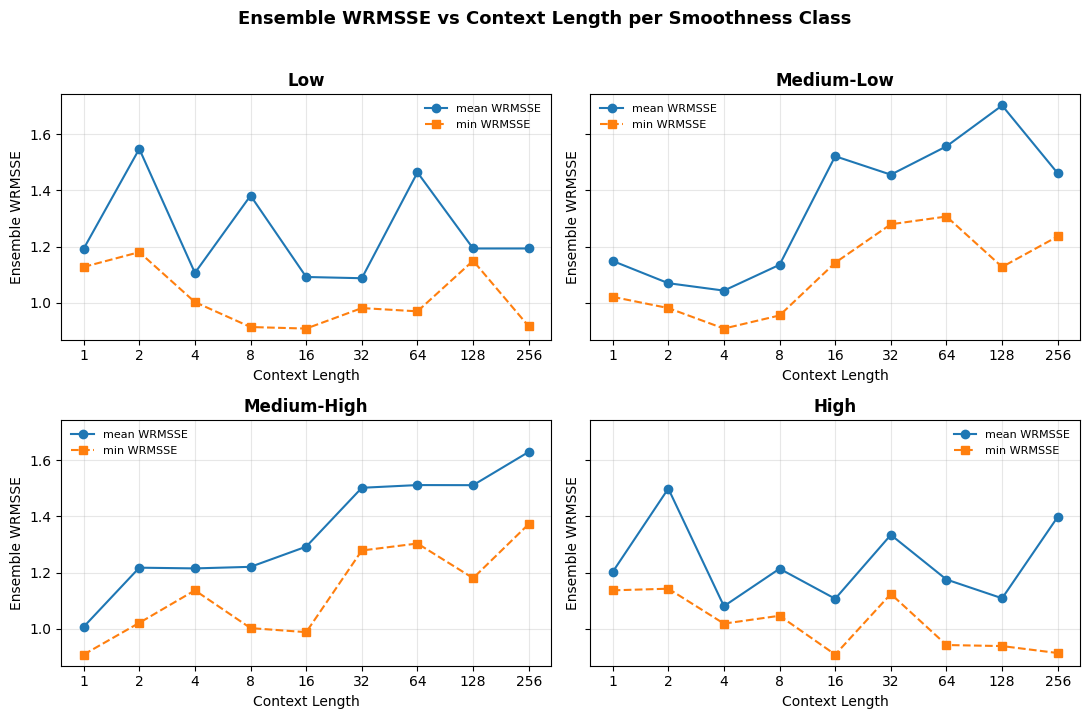

In [25]:
# Per-segment CL vs WRMSSE — shows which class benefits most from longer context
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
axes = axes.flatten()

for ax, (seg, param) in zip(axes, SEG_PARAM.items()):
    col = f"params_{param}"
    grouped = df_trials.groupby(col)["WRMSSE"].agg(["mean", "min"]).reset_index()
    ax.plot(grouped[col], grouped["mean"], marker="o", label="mean WRMSSE")
    ax.plot(grouped[col], grouped["min"],  marker="s", linestyle="--", label="min WRMSSE")
    ax.set_xscale("log", base=2)
    ax.set_title(seg, fontweight="bold")
    ax.set_xlabel("Context Length")
    ax.set_ylabel("Ensemble WRMSSE")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.legend(frameon=False, fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Ensemble WRMSSE vs Context Length per Smoothness Class",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [26]:
from pathlib import Path

out = Path(f"/mnt/lab/nmwamsojo/results/m5_hpo_cl_ensemble_{CUTOFF_DAY.replace('-', '')}.csv")
out.parent.mkdir(parents=True, exist_ok=True)
df_trials.to_csv(out, index=False)
print(f"Results saved → {out}  ({len(df_trials)} rows)")

Results saved → /mnt/lab/nmwamsojo/results/m5_hpo_cl_ensemble_20160424.csv  (100 rows)
